In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [18]:
df = pd.read_csv('The_Cancer_data_1500_V2 (1).csv')

In [19]:
df.shape

(1500, 9)

In [20]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='str')

In [21]:
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [22]:
df.isna().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [23]:
df.describe()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


In [24]:
df.Diagnosis.value_counts()

Diagnosis
0    943
1    557
Name: count, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [26]:
X = df[['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']]
y = df['Diagnosis']

scaler = StandardScaler()
X[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']] = scaler.fit_transform(X[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']])


In [27]:
X

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory
0,0.435495,1,-1.581162,0,1,1.133713,1.219465,1
1,1.172662,0,0.458722,0,1,1.557899,0.776474,0
2,-0.131556,1,1.559544,0,2,0.082804,1.628353,0
3,-0.925428,0,0.349628,0,0,1.607166,-0.263137,0
4,0.662316,1,1.102219,0,0,0.160184,0.628583,0
...,...,...,...,...,...,...,...,...
1495,0.662316,1,-0.335284,0,0,1.743064,-0.799122,0
1496,-1.095543,0,0.820992,0,1,-1.127190,-0.096805,1
1497,0.719021,1,0.705703,1,1,-1.546514,-1.598404,0
1498,0.265380,0,-0.269122,0,0,1.011232,-0.304367,1


In [28]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=42)
Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((1125, 8), (375, 8), (1125,), (375,))

In [29]:
rfclf = RandomForestClassifier(n_estimators=20)
rfclf.fit(Xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [30]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [33]:
ypred = rfclf.predict(Xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       233
           1       0.92      0.86      0.89       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.91       375
weighted avg       0.92      0.92      0.92       375



Confusion Matrix for rfclf:
[[222  11]
 [ 20 122]]


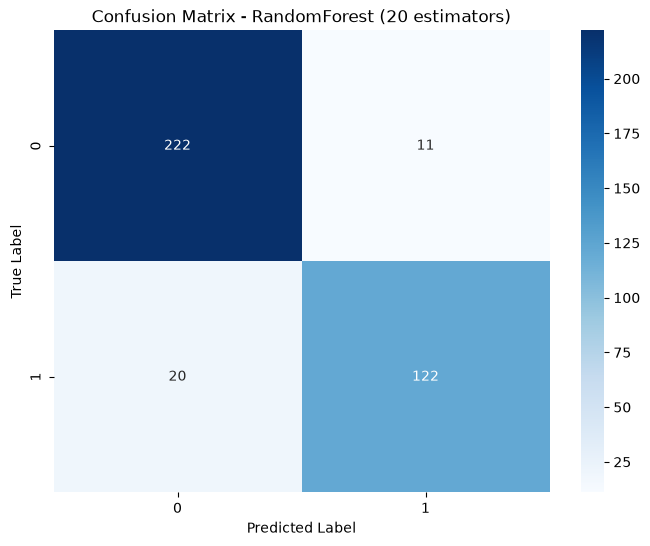


Confusion Matrix for rfclf2:
[[222  11]
 [ 19 123]]


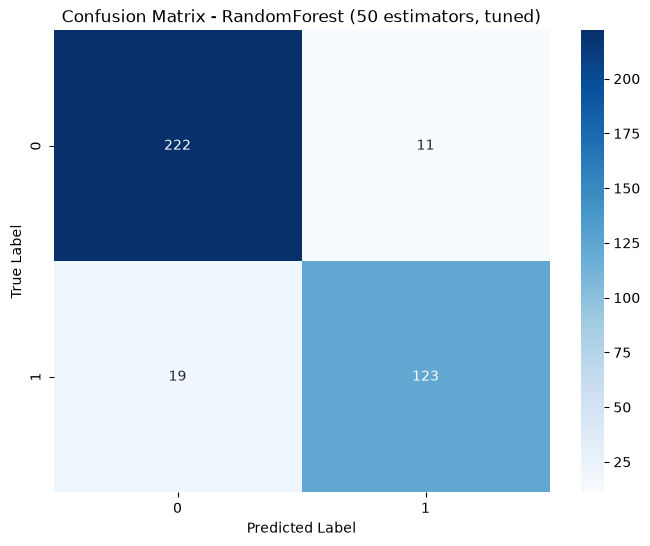

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Generate confusion matrix for rfclf
cm1 = confusion_matrix(ytest, ypred)
print("Confusion Matrix for rfclf:")
print(cm1)

# Visualize confusion matrix for rfclf
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest (20 estimators)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate confusion matrix for rfclf2
cm2 = confusion_matrix(ytest, ypred2)
print("\nConfusion Matrix for rfclf2:")
print(cm2)

# Visualize confusion matrix for rfclf2
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest (50 estimators, tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [35]:
rfparams = {
    'n_estimators':50,
    'max_features':'log2',
    'criterion':'entropy',
    'bootstrap': False,
    'max_depth':15,
    'min_samples_split':5,
    'min_samples_leaf':3
}
rfclf2 = RandomForestClassifier(**rfparams)
rfclf2.fit(Xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [37]:
ypred2 = rfclf2.predict(Xtest)

In [38]:
print(classification_report(ypred2, ytest))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       241
           1       0.87      0.92      0.89       134

    accuracy                           0.92       375
   macro avg       0.91      0.92      0.91       375
weighted avg       0.92      0.92      0.92       375



In [44]:
import joblib

joblib.dump(rfclf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [43]:
import gradio as gr
import subprocess, sys
import gradio as gr
import pandas as pd
import gradio
import gradio

# Use the existing trained model and scaler from the notebook
feature_names = X.columns.tolist()
scale_columns = ["Age", "BMI", "PhysicalActivity", "AlcoholIntake"]

def predict_diagnosis(age, gender, bmi, smoking, genetic_risk, physical_activity, alcohol_intake, cancer_history):
    input_df = pd.DataFrame(
        [[age, gender, bmi, smoking, genetic_risk, physical_activity, alcohol_intake, cancer_history]],
        columns=feature_names
    )

    # Apply the same preprocessing used during training
    input_df[scale_columns] = scaler.transform(input_df[scale_columns])

    probs = rfclf.predict_proba(input_df)[0]
    pred_index = int(probs.argmax())
    pred_label = "Cancer" if pred_index == 1 else "No Cancer"
    confidence = float(probs[pred_index])

    return f"{pred_label} (Diagnosis = {pred_index})", f"{confidence:.2%}"

demo = gr.Interface(
    fn=predict_diagnosis,
    inputs=[
        gr.Number(label="Age", value=50, precision=0),
        gr.Dropdown(label="Gender", choices=[("Female", 0), ("Male", 1)], value=1),
        gr.Number(label="BMI", value=28.5, precision=2),
        gr.Dropdown(label="Smoking", choices=[("No", 0), ("Yes", 1)], value=0),
        gr.Dropdown(label="Genetic Risk", choices=[("0", 0), ("1", 1), ("2", 2)], value=1),
        gr.Number(label="Physical Activity", value=5.0, precision=2),
        gr.Number(label="Alcohol Intake", value=2.5, precision=2),
        gr.Dropdown(label="Cancer History", choices=[("No", 0), ("Yes", 1)], value=0),
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence")
    ],
    title="Cancer Diagnosis Predictor",
    description="Enter the patient health details below to check the model's diagnosis prediction.",
    examples=[
        [58, 1, 16.08, 0, 1, 8.15, 4.15, 1],
        [45, 0, 28.4, 1, 0, 6.2, 3.1, 0],
        [63, 1, 32.6, 1, 1, 0.5, 0.15, 0],
    ]
)

demo.launch()

c:\Users\indal\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
